In [2]:
import os
import glob
import re
import warnings

import numpy as np
import pandas as pd
from scipy import stats
from pingouin import mixed_anova, pairwise_tests
from IPython.display import display

warnings.filterwarnings("ignore")

# ============================================================
# CELL 1: DATASET LOADING + PREPROCESSING (CONSISTENT PIPELINE)
# ============================================================
GROUP_FOLDERS = {
    "Task-Only": "./MST_Data/task_only/task_only_data",
    "Both": "./MST_Data/Both_item_task/both_data",
    "Item-Only": "./MST_Data/item_only/item_only_data",
}


def normalize_response(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    if "old" in s:
        return "Old"
    if "similar" in s:
        return "Similar"
    if "new" in s:
        return "New"
    if "o" == s:
        return "Old"
    if "s" == s:
        return "Similar"
    if "n" == s:
        return "New"
    m = re.search(r"[osn]", s)
    if not m:
        return None
    return {"o": "Old", "s": "Similar", "n": "New"}.get(m.group(0), None)


def normalize_position(x):
    if pd.isna(x):
        return None
    p = str(x).strip().lower()
    return {"pre": "Pre", "mid": "Mid", "post": "Post", "none": "Foil"}.get(p, None)


def classify_item_type(image_path):
    if pd.isna(image_path):
        return None
    s = str(image_path).replace("\\", "/")
    if s.lower().startswith("foil"):
        return "Foil"
    bn = os.path.basename(s)
    if bn.endswith("a.jpg"):
        return "Target"
    if bn.endswith("b.jpg"):
        return "Lure"
    return None


def parse_task_file(filepath, group):
    try:
        df = pd.read_csv(filepath)
    except Exception:
        return None

    # Keep participant id convention from other notebooks: filename prefix
    pid = os.path.basename(filepath)[:5]

    trials = df[df["trials.thisN"].notna()].copy() if "trials.thisN" in df.columns else df.copy()
    if len(trials) == 0:
        return None

    if "encoding_task_accuracy" in df.columns:
        enc_acc = df["encoding_task_accuracy"].dropna()
        acc = float(enc_acc.iloc[-1]) if len(enc_acc) > 0 else np.nan
    else:
        acc = np.nan

    return {
        "participant": pid,
        "group": group,
        "enc_accuracy": acc,
    }


def parse_test_file(filepath, group):
    try:
        df = pd.read_csv(filepath)
    except Exception:
        return None

    pid = os.path.basename(filepath)[:5]

    trials = df[df["image_path"].notna()].copy() if "image_path" in df.columns else df.copy()
    if len(trials) == 0:
        return None

    required = ["image_path", "key_resp_3.keys", "position_of_stimuli"]
    if not all(col in trials.columns for col in required):
        return None

    trials["item_type"] = trials["image_path"].apply(classify_item_type)
    trials["position"] = trials["position_of_stimuli"].apply(normalize_position)
    trials["response"] = trials["key_resp_3.keys"].apply(normalize_response)

    foils = trials[trials["item_type"] == "Foil"]
    n_f = len(foils[foils["response"].notna()])
    if n_f == 0:
        return None

    p_old_foil = (foils["response"] == "Old").sum() / n_f
    p_sim_foil = (foils["response"] == "Similar").sum() / n_f

    out = {
        "participant": pid,
        "group": group,
        "foil_far": p_old_foil,
    }

    for pos in ["Pre", "Mid", "Post"]:
        pos_trials = trials[trials["position"] == pos]

        targs = pos_trials[pos_trials["item_type"] == "Target"]
        nt = len(targs[targs["response"].notna()])
        p_old_t = (targs["response"] == "Old").sum() / nt if nt else np.nan

        lures = pos_trials[pos_trials["item_type"] == "Lure"]
        nl = len(lures[lures["response"].notna()])
        p_sim_l = (lures["response"] == "Similar").sum() / nl if nl else np.nan

        out[f"REC_{pos}"] = p_old_t - p_old_foil if not np.isnan(p_old_t) else np.nan
        out[f"LDI_{pos}"] = p_sim_l - p_sim_foil if not np.isnan(p_sim_l) else np.nan

    return out


all_task = []
all_test = []

for group, folder in GROUP_FOLDERS.items():
    files = sorted(glob.glob(os.path.join(folder, "*.csv")))

    # Keep one task/test file per participant using filename prefix, like other notebooks
    task_by_id = {os.path.basename(f)[:5]: f for f in files if "_task_" in os.path.basename(f)}
    test_by_id = {os.path.basename(f)[:5]: f for f in files if "_test_" in os.path.basename(f)}
    valid_ids = sorted(set(task_by_id) & set(test_by_id))

    print(f"{group}: paired participants={len(valid_ids)}")

    for pid in valid_ids:
        tr = parse_task_file(task_by_id[pid], group)
        te = parse_test_file(test_by_id[pid], group)
        if tr is not None:
            all_task.append(tr)
        if te is not None:
            all_test.append(te)


task_info = pd.DataFrame(all_task)
test_info = pd.DataFrame(all_test)

print(f"Parsed task participants: {task_info.groupby(['participant','group']).ngroups}")
print(f"Parsed test participants: {test_info.groupby(['participant','group']).ngroups}")


data = pd.merge(task_info, test_info, on=["participant", "group"])
data["subject_id"] = data["group"] + "_" + data["participant"]

required_cols = ["REC_Pre", "REC_Mid", "REC_Post", "LDI_Pre", "LDI_Mid", "LDI_Post"]
before = len(data)

# data = data[data["enc_accuracy"] >= 0.60]
# data = data[data["foil_far"] <= 0.50]
# data = data.dropna(subset=required_cols)

after = len(data)
print(f"Excluded {before - after} participants | Remaining: {after}")
print(data["group"].value_counts(dropna=False))


def to_long(df, metric):
    rows = []
    for _, row in df.iterrows():
        for pos in ["Pre", "Mid", "Post"]:
            rows.append(
                {
                    "participant": row["participant"],
                    "subject_id": row["subject_id"],
                    "group": row["group"],
                    "position": pos,
                    metric: row[f"{metric}_{pos}"],
                }
            )
    return pd.DataFrame(rows, columns=["participant", "subject_id", "group", "position", metric])


rec_long = to_long(data, "REC")
ldi_long = to_long(data, "LDI")

print(f"REC long rows: {len(rec_long)} | LDI long rows: {len(ldi_long)}")
print("REC columns:", rec_long.columns.tolist())
print("LDI columns:", ldi_long.columns.tolist())

Task-Only: paired participants=53
Both: paired participants=49
Item-Only: paired participants=56
Parsed task participants: 158
Parsed test participants: 158
Excluded 0 participants | Remaining: 158
group
Item-Only    56
Task-Only    53
Both         49
Name: count, dtype: int64
REC long rows: 474 | LDI long rows: 474
REC columns: ['participant', 'subject_id', 'group', 'position', 'REC']
LDI columns: ['participant', 'subject_id', 'group', 'position', 'LDI']


In [3]:
# ==============================================
# CELL 2: RUN ASSUMPTION CHECKS + MIXED ANOVA
# ==============================================
import pingouin as pg

if len(data) == 0:
    raise ValueError("No participants remain after exclusions.")

for df_name, df_obj, dv in [("rec_long", rec_long, "REC"), ("ldi_long", ldi_long, "LDI")]:
    needed = {"subject_id", "group", "position", dv}
    missing = needed - set(df_obj.columns)
    if missing:
        raise ValueError(f"{df_name} is missing required columns: {sorted(missing)}")
    if df_obj[dv].dropna().empty:
        raise ValueError(f"{df_name}.{dv} has no non-missing values.")

# --- Levene's Test (homogeneity of variance across groups) ---
print("Levene tests (across groups)")
for metric in ["REC_Post", "REC_Pre", "LDI_Pre"]:
    group_vals = [
        data.loc[data["group"] == g, metric].dropna().values
        for g in ["Item-Only", "Task-Only", "Both"]
    ]
    group_vals = [v for v in group_vals if len(v) > 0]
    if len(group_vals) >= 2:
        stat, p = stats.levene(*group_vals)
        note = "Equal variances" if p > 0.05 else "Unequal variances"
        print(f"  {metric}: F={stat:.3f}, p={p:.3f} -> {note}")
    else:
        print(f"  {metric}: skipped (insufficient group data)")

# --- Mauchly's Sphericity Test (for within-subject factor: position) ---
print("\nMauchly's Sphericity Tests")
for label, df_obj, dv in [("REC", rec_long, "REC"), ("LDI", ldi_long, "LDI")]:
    spher, W, chi2, dof, p = pg.sphericity(
        data=df_obj,
        dv=dv,
        within="position",
        subject="subject_id"
    )
    note = "Sphericity assumed" if spher else "Sphericity violated — use GG correction"
    print(f"  {label}: W={W:.3f}, chi2={chi2:.3f}, df={dof}, p={p:.3f} -> {note}")

Levene tests (across groups)
  REC_Post: F=1.485, p=0.230 -> Equal variances
  REC_Pre: F=0.795, p=0.453 -> Equal variances
  LDI_Pre: F=0.670, p=0.513 -> Equal variances

Mauchly's Sphericity Tests
  REC: W=0.969, chi2=4.890, df=2, p=0.087 -> Sphericity assumed
  LDI: W=0.988, chi2=1.808, df=2, p=0.405 -> Sphericity assumed


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pingouin as pg   # pip install pingouin

# ── Assumption: No data structure assumed — adapt column names to your df ───
# Expected: df with columns: participant, group, REC_Post, REC_Pre, LDI_Pre
# (wide format, one row per participant)

# ============================================================
# CHECK 1: OUTLIER DETECTION — IQR method per cell
# ============================================================

def detect_outliers_iqr(df, metric, group_col="group"):
    """
    Returns dataframe of outliers (mild: >1.5*IQR) and 
    extreme outliers (>3*IQR) per group.
    """
    results = []
    for grp, gdf in df.groupby(group_col):
        vals = gdf[metric].dropna()
        Q1, Q3 = vals.quantile(0.25), vals.quantile(0.75)
        IQR = Q3 - Q1
        mild_lo, mild_hi   = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        extreme_lo, extreme_hi = Q1 - 3.0 * IQR, Q3 + 3.0 * IQR

        for idx, row in gdf.iterrows():
            v = row[metric]
            if pd.isna(v): continue
            is_outlier = v < mild_lo or v > mild_hi
            is_extreme = v < extreme_lo or v > extreme_hi
            if is_outlier:
                results.append({
                    "participant": row["participant"],
                    "group":       grp,
                    "metric":      metric,
                    "value":       v,
                    "is_outlier":  True,
                    "is_extreme":  is_extreme
                })
    return pd.DataFrame(results)

print("=" * 55)
print("OUTLIER DETECTION (IQR method per group per metric)")
print("=" * 55)

for metric in ["REC_Post", "REC_Pre", "LDI_Pre"]:
    out_df = detect_outliers_iqr(data, metric)
    if out_df.empty:
        print(f"\n{metric}: No outliers detected")
    else:
        n_mild    = len(out_df[~out_df["is_extreme"]])
        n_extreme = len(out_df[out_df["is_extreme"]])
        print(f"\n{metric}: {n_mild} mild outliers, {n_extreme} EXTREME outliers")
        if n_extreme > 0:
            print(out_df[out_df["is_extreme"]][
                ["participant", "group", "value"]].to_string(index=False))

# ============================================================
# CHECK 2: HOMOGENEITY OF COVARIANCES — Box's M Test
# ============================================================
# pingouin's box_m() requires wide format:
# one row per participant, DV columns = within-subjects levels

print("\n" + "=" * 55)
print("BOX'S M TEST (Homogeneity of Covariance Matrices)")
print("=" * 55)
print("Note: Use p < 0.001 threshold (test is sensitive to N)")

# --- REC: covariance across REC_Pre, REC_Post, REC_Mid ---
rec_cols = ["REC_Pre", "REC_Post", "REC_Mid"]   # adjust if column names differ
rec_wide_clean = data[["participant", "group"] + rec_cols].dropna()

boxm_rec = pg.box_m(
    data     = rec_wide_clean,
    dvs      = rec_cols,
    group    = "group"
)
print("\n--- REC Model ---")
print(boxm_rec.to_string())

# Safely extract chi2/p-value from pingouin output (columns can vary by version)
p_val = boxm_rec["pval"].values[0]
note  = "Homogeneous (p > 0.001)" if p_val > 0.001 else "Heterogeneous (p ≤ 0.001)"
print(f"p = {p_val:.4f} → {note}")

# --- LDI: covariance across LDI_Pre and any Mid/Foil baseline ---
ldi_cols = ["LDI_Pre", "LDI_Mid"]   # adjust to your actual column names
ldi_wide_clean = data[["participant", "group"] + ldi_cols].dropna()

if all(c in data.columns for c in ldi_cols):
    boxm_ldi = pg.box_m(
        data  = ldi_wide_clean,
        dvs   = ldi_cols,
        group = "group"
    )
    print("\n--- LDI Model ---")
    print(boxm_ldi.to_string())

    p_val_ldi = boxm_ldi["pval"].values[0]
    note_ldi = "Homogeneous (p > 0.001)" if p_val_ldi > 0.001 else "Heterogeneous (p ≤ 0.001)"
    print(f"  p = {p_val_ldi:.4f} → {note_ldi}")
else:
    print("\nLDI: Adjust ldi_cols to match your actual column names")


OUTLIER DETECTION (IQR method per group per metric)

REC_Post: 1 mild outliers, 0 EXTREME outliers

REC_Pre: 2 mild outliers, 0 EXTREME outliers

LDI_Pre: No outliers detected

BOX'S M TEST (Homogeneity of Covariance Matrices)
Note: Use p < 0.001 threshold (test is sensitive to N)

--- REC Model ---
         Chi2    df      pval  equal_cov
box  9.318217  12.0  0.675537       True
p = 0.6755 → Homogeneous (p > 0.001)

--- LDI Model ---
         Chi2   df      pval  equal_cov
box  6.919476  6.0  0.328358       True
  p = 0.3284 → Homogeneous (p > 0.001)


In [5]:
# ==============================================
# CELL 3: DISPLAY RESULTS + CONDITIONAL POST-HOC
# ==============================================
def interaction_pvalue(aov_df):
    src = aov_df["Source"].astype(str).str.lower()

    # Pingouin can label the term either as "Interaction" or explicit factor names
    mask = src.eq("interaction") | (src.str.contains("position") & src.str.contains("group"))
    if mask.any():
        p_col = "p-unc" if "p-unc" in aov_df.columns else "p_unc"
        return float(aov_df.loc[mask, p_col].iloc[0])
    return np.nan

rec_aov = pg.mixed_anova(
    data=rec_long, dv="REC",
    within="position", between="group",
    subject="subject_id"
)

ldi_aov = pg.mixed_anova(
    data=ldi_long, dv="LDI",
    within="position", between="group",
    subject="subject_id"
)

print("\n" + "=" * 40)
print("Mixed ANOVA - REC")
print("=" * 40)
display(rec_aov)

print("\n" + "=" * 40)
print("Mixed ANOVA - LDI")
print("=" * 40)
display(ldi_aov)

for label, aov, long_df, dv in [
    ("REC", rec_aov, rec_long, "REC"),
    ("LDI", ldi_aov, ldi_long, "LDI"),
]:
    p_int = interaction_pvalue(aov)

    print(f"\nPost-hoc: {label} (Bonferroni corrected)")
    ph = pairwise_tests(
        data=long_df,
        dv=dv,
        within="position",
        between="group",
        subject="subject_id",
        padjust="bonf",
    )

    # Keep key columns and include within-level info (position) when available.
    base_cols = ["Contrast", "A", "B", "p-unc", "p_unc", "p-corr", "p_corr", "hedges"]
    keep_cols = [c for c in base_cols if c in ph.columns]

    if "position" in ph.columns and "position" not in keep_cols:
        keep_cols.insert(1, "position")

    # Fallback for versions that store within-level label under another column.
    for alt_col in ["Within", "within", "within_level", "level"]:
        if alt_col in ph.columns and alt_col not in keep_cols:
            keep_cols.insert(1, alt_col)
            break

    display(ph[keep_cols])



Mixed ANOVA - REC


,Source,SS,DF1,DF2,MS,F,p_unc,np2,eps
0,group,0.136277,2,155,0.068139,0.929231,0.397045,0.011848,NaN
1,position,0.134462,2,310,0.067231,6.217785,0.002251,0.038568,0.970061
2,Interaction,0.110269,4,310,0.027567,2.549536,0.039327,0.031849,NaN



Mixed ANOVA - LDI


,Source,SS,DF1,DF2,MS,F,p_unc,np2,eps
0,group,0.933783,2,155,0.466891,4.899435,0.008645,0.059460,NaN
1,position,0.010011,2,310,0.005005,0.432821,0.649068,0.002785,0.988606
2,Interaction,0.045058,4,310,0.011265,0.974085,0.421860,0.012413,NaN



Post-hoc: REC (Bonferroni corrected)


,Contrast,position,A,B,p_unc,p_corr,hedges
0,position,-,Mid,Post,0.003340,0.010020,0.203691
1,position,-,Mid,Pre,0.746890,1.000000,0.020072
2,position,-,Post,Pre,0.005678,0.017034,-0.189030
3,group,-,Both,Item-Only,0.264802,0.794405,-0.216225
4,group,-,Both,Task-Only,0.843873,1.000000,0.038490
5,group,-,Item-Only,Task-Only,0.230374,0.691121,0.230409
6,position * group,Mid,Both,Item-Only,0.863796,1.000000,-0.033307
7,position * group,Mid,Both,Task-Only,0.343238,1.000000,0.186820
8,position * group,Mid,Item-Only,Task-Only,0.259181,1.000000,0.216026
9,position * group,Post,Both,Item-Only,0.032582,0.293236,-0.416488



Post-hoc: LDI (Bonferroni corrected)


,Contrast,position,A,B,p_unc,p_corr,hedges
0,position,-,Mid,Post,0.409184,1.000000,0.052036
1,position,-,Mid,Pre,0.441952,1.000000,0.043654
2,position,-,Post,Pre,0.896555,1.000000,-0.007697
3,group,-,Both,Item-Only,0.155208,0.465625,-0.278954
4,group,-,Both,Task-Only,0.002976,0.008929,-0.597486
5,group,-,Item-Only,Task-Only,0.076445,0.229335,-0.341494
6,position * group,Mid,Both,Item-Only,0.349491,1.000000,-0.184536
7,position * group,Mid,Both,Task-Only,0.058798,0.529184,-0.379312
8,position * group,Mid,Item-Only,Task-Only,0.274158,1.000000,-0.208915
9,position * group,Post,Both,Item-Only,0.119122,1.000000,-0.307045


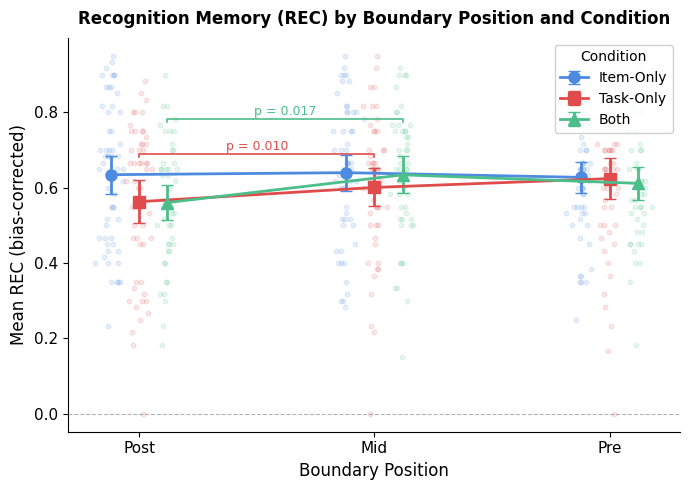

Saved: figures/anova_rec_interaction.png


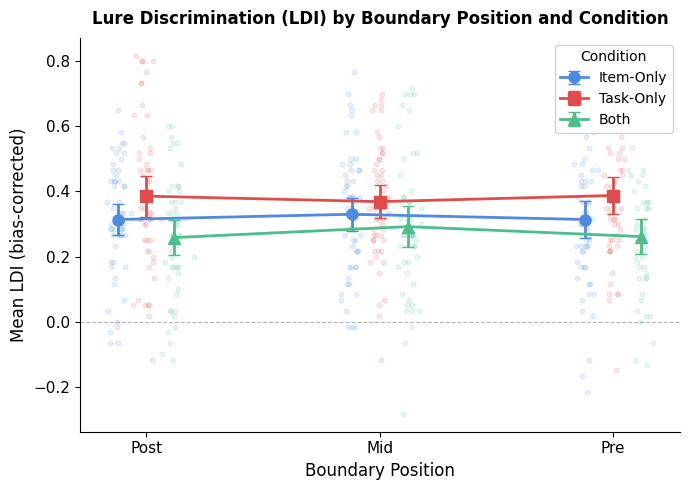

Saved: figures/anova_ldi_interaction.png


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

POSITION_ORDER = ["Post", "Mid", "Pre"]
CONDITION_ORDER = ["Item-Only", "Task-Only", "Both"]
COLORS = {"Item-Only": "#4C8BE0", "Task-Only": "#E04C4C", "Both": "#4CBE8B"}
MARKERS = {"Item-Only": "o", "Task-Only": "s", "Both": "^"}
JITTER  = {"Item-Only": -0.12, "Task-Only": 0.0, "Both": 0.12}


def pval_label(p):
    if p < 0.001:
        return "p < .001"
    else:
        return f"p = {p:.3f}"


def bracket_annotation(ax, x1, x2, y, label, color="black", fontsize=9):
    h = 0.008
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color=color, linewidth=1.2)
    ax.text((x1 + x2) / 2, y + h + 0.003, label,
            ha="center", va="bottom", fontsize=fontsize, color=color)


def compute_emm_ci(df, dv):
    rows = []
    for cond in CONDITION_ORDER:
        for pos in POSITION_ORDER:
            vals = df[(df["group"] == cond) & (df["position"] == pos)][dv].dropna()
            n = len(vals)
            mean = vals.mean()
            se = vals.std(ddof=1) / np.sqrt(n)
            ci = stats.t.ppf(0.975, df=n - 1) * se
            rows.append({"condition": cond, "position": pos,
                         "mean": mean, "ci": ci, "n": n})
    return pd.DataFrame(rows)


def plot_rec(df, save_path):
    emm = compute_emm_ci(df, "REC")
    x_map = {pos: i for i, pos in enumerate(POSITION_ORDER)}

    fig, ax = plt.subplots(figsize=(7, 5))

    for cond in CONDITION_ORDER:
        for pos in POSITION_ORDER:
            vals = df[(df["group"] == cond) & (df["position"] == pos)]["REC"].dropna()
            x_j = np.random.normal(x_map[pos] + JITTER[cond], 0.022, size=len(vals))
            ax.scatter(x_j, vals, alpha=0.13, s=11, color=COLORS[cond], zorder=1)

    for cond in CONDITION_ORDER:
        sub = emm[emm["condition"] == cond].set_index("position").loc[POSITION_ORDER]
        x = np.array([x_map[p] + JITTER[cond] for p in POSITION_ORDER])
        ax.errorbar(x, sub["mean"], yerr=sub["ci"],
                    fmt=f"-{MARKERS[cond]}", color=COLORS[cond],
                    linewidth=2, markersize=8, capsize=4, zorder=3, label=cond)

    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

    for cond, p_val, extra_offset in [("Task-Only", 0.010020, 0.0),
                                       ("Both",      0.017034, 0.06)]:
        sub = emm[emm["condition"] == cond].set_index("position")
        y_post = sub.loc["Post", "mean"] + sub.loc["Post", "ci"]
        y_mid  = sub.loc["Mid",  "mean"] + sub.loc["Mid",  "ci"]
        y_base = max(y_post, y_mid) + 0.03 + extra_offset
        x1 = x_map["Post"] + JITTER[cond]
        x2 = x_map["Mid"]  + JITTER[cond]
        bracket_annotation(ax, x1, x2, y_base,
                           pval_label(p_val), color=COLORS[cond], fontsize=9)

    ax.set_xticks(range(len(POSITION_ORDER)))
    ax.set_xticklabels(POSITION_ORDER, fontsize=12)
    ax.set_xlabel("Boundary Position", fontsize=12)
    ax.set_ylabel("Mean REC (bias-corrected)", fontsize=12)
    ax.set_title("Recognition Memory (REC) by Boundary Position and Condition",
                 fontsize=12, fontweight="bold", pad=10)
    ax.legend(title="Condition", fontsize=10, title_fontsize=10,
              framealpha=0.9, loc="upper right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=11)

    plt.tight_layout()
    os.makedirs("figures", exist_ok=True)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


def plot_ldi(df, save_path):
    emm = compute_emm_ci(df, "LDI")
    x_map = {pos: i for i, pos in enumerate(POSITION_ORDER)}

    fig, ax = plt.subplots(figsize=(7, 5))

    for cond in CONDITION_ORDER:
        for pos in POSITION_ORDER:
            vals = df[(df["group"] == cond) & (df["position"] == pos)]["LDI"].dropna()
            x_j = np.random.normal(x_map[pos] + JITTER[cond], 0.022, size=len(vals))
            ax.scatter(x_j, vals, alpha=0.13, s=11, color=COLORS[cond], zorder=1)

    for cond in CONDITION_ORDER:
        sub = emm[emm["condition"] == cond].set_index("position").loc[POSITION_ORDER]
        x = np.array([x_map[p] + JITTER[cond] for p in POSITION_ORDER])
        ax.errorbar(x, sub["mean"], yerr=sub["ci"],
                    fmt=f"-{MARKERS[cond]}", color=COLORS[cond],
                    linewidth=2, markersize=8, capsize=4, zorder=3, label=cond)

    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

    ax.set_xticks(range(len(POSITION_ORDER)))
    ax.set_xticklabels(POSITION_ORDER, fontsize=12)
    ax.set_xlabel("Boundary Position", fontsize=12)
    ax.set_ylabel("Mean LDI (bias-corrected)", fontsize=12)
    ax.set_title("Lure Discrimination (LDI) by Boundary Position and Condition",
                 fontsize=12, fontweight="bold", pad=10)
    ax.legend(title="Condition", fontsize=10, title_fontsize=10,
              framealpha=0.9, loc="upper right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=11)

    plt.tight_layout()
    os.makedirs("figures", exist_ok=True)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


# ── Run ───────────────────────────────────────────────────────────────────────
plot_rec(rec_long, "figures/anova_rec_interaction.png")
plot_ldi(ldi_long, "figures/anova_ldi_interaction.png")